# Notebook to generate figures for the GSP poster

In [1]:
import pathlib

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the data

In [2]:
output_folder = pathlib.Path("../../data/outputs_nosync/")
output_folder_leaf = output_folder / "outputs_leaf"
output_folder_ch = output_folder / "outputs_ch"
prediction_runs = []
prediction_runs.extend([fol for fol in output_folder_leaf.iterdir() if fol.is_dir()])
prediction_runs.extend([fol for fol in output_folder_ch.iterdir() if fol.is_dir()])
prediction_runs

[PosixPath('../../data/outputs_nosync/outputs_leaf/biolog_mutual_info_1000'),
 PosixPath('../../data/outputs_nosync/outputs_leaf/biolog'),
 PosixPath('../../data/outputs_nosync/outputs_leaf/biolog_pca_200'),
 PosixPath('../../data/outputs_nosync/outputs_leaf/biolog_chi2_1000'),
 PosixPath('../../data/outputs_nosync/outputs_leaf/biolog_nmf_200'),
 PosixPath('../../data/outputs_nosync/outputs_leaf/biolog_f_1000'),
 PosixPath('../../data/outputs_nosync/outputs_ch/biolog_mutual_info_1000'),
 PosixPath('../../data/outputs_nosync/outputs_ch/biolog'),
 PosixPath('../../data/outputs_nosync/outputs_ch/biolog_pca_200'),
 PosixPath('../../data/outputs_nosync/outputs_ch/biolog_chi2_1000'),
 PosixPath('../../data/outputs_nosync/outputs_ch/biolog_nmf_200'),
 PosixPath('../../data/outputs_nosync/outputs_ch/biolog_f_1000')]

In [3]:
def read_csv_files(folder_list: list[pathlib.Path], file_name: str, reindex: bool = True):
    df_list = []
    for folder in folder_list:
        file_path = folder / file_name
        df = pd.read_csv(file_path, index_col=0)
        df_list.append(df)
    df_concat = pd.concat(df_list)
    if reindex:
        df_concat.index = list(range(df_concat.shape[0])) # type: ignore
    return df_concat

In [4]:
cv_scores_df = read_csv_files(prediction_runs, "all_feat_cv_scores_data.csv", reindex=True)

In [5]:
col_dict = {
    "accuracy": "Accuracy",
    "balanced_accuracy": "Balanced Accuracy",
    "precision": "Precision",
    "recall": "Recall",
    "f1": "F1",
    "roc_auc": "ROC AUC",
    "matthews_corrcoef": "MCC",
    "name": "Phenotype",
    "category": "Dataset",
    "fold_num": "fold_num",
    "feature": "Feature representation",
    "run_id": "Preprocessing strategy"
}

cv_scores_df = cv_scores_df.rename(columns=col_dict)

In [6]:
cv_scores_df["Dataset"] = cv_scores_df["Dataset"].replace({"leaf_biolog": "AT leaf", "ch_biolog": "Literature"})
cv_scores_df["Preprocessing strategy"] = cv_scores_df["Preprocessing strategy"].replace(
    {
        "biolog": "Unprocessed",
        "biolog_chi2_1000": "Chi2(1000)",
        "biolog_f_1000": "F(1000)",
        "biolog_mutual_info_1000": "Mutual info(1000)",
        "biolog_nmf_200": "NMF(200)",
        "biolog_pca_200": "PCA(200)",
    }
)
cv_scores_df

,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC AUC,MCC,Phenotype,Dataset,fold_num,Feature representation,Preprocessing strategy
0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,Oxalate,AT leaf,1,cluster30,Mutual info(1000)
1,0.950000,0.972222,0.666667,1.000000,0.800000,0.958333,0.793492,Oxalate,AT leaf,2,cluster30,Mutual info(1000)
2,0.950000,0.861111,0.750000,0.750000,0.750000,0.972222,0.722222,Oxalate,AT leaf,3,cluster30,Mutual info(1000)
3,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,Oxalate,AT leaf,4,cluster30,Mutual info(1000)
4,0.975000,0.875000,1.000000,0.750000,0.857143,1.000000,0.854242,Oxalate,AT leaf,5,cluster30,Mutual info(1000)
...,...,...,...,...,...,...,...,...,...,...,...,...
43675,0.877193,0.876232,0.843750,0.931034,0.885246,0.944581,0.758086,Carbon-a-D-Lactose,Literature,1,uniref90,F(1000)
43676,0.824561,0.822660,0.771429,0.931034,0.843750,0.847291,0.662686,Carbon-a-D-Lactose,Literature,2,uniref90,F(1000)
43677,0.625000,0.625000,0.571429,1.000000,0.727273,0.751913,0.377964,Carbon-a-D-Lactose,Literature,3,uniref90,F(1000)
43678,0.482143,0.482143,0.489362,0.821429,0.613333,0.713648,-0.048622,Carbon-a-D-Lactose,Literature,4,uniref90,F(1000)


In [7]:
score_columns = ["Balanced Accuracy", "MCC", "ROC AUC"]

In [8]:
def group_feature(feature: str) -> str:
    denovo_features = [
        "cluster30",
        "cluster50",
        "cluster70",
        "cluster90",
    ]
    metabolic_features = [
        "eggnog_kegg",
        "eggnog_seed",
        "kofam",
        "kofam_modules",
        "rast",
    ]
    protein_features = [
        "uniprot_trembl",
        "uniref30",
        "uniref50",
        "uniref70",
        "uniref90",
    ]
    if feature in metabolic_features:
        return "Metabolic"
    elif feature in protein_features:
        return "Protein"
    elif feature in denovo_features:
        return "De novo"
    else:
        raise ValueError(f"Feature {feature} not found in any group")

## Performance of different feature selection/reduction methods

In [9]:
cols = ["Preprocessing strategy", "Dataset"] + score_columns
(
    cv_scores_df
    .loc[:, cols]
    .groupby(by=["Dataset", "Preprocessing strategy"])
    .mean()
    .reset_index()
    .sort_values("Balanced Accuracy", ascending=False)
)

,Dataset,Preprocessing strategy,Balanced Accuracy,MCC,ROC AUC
0,AT leaf,Chi2(1000),0.827647,0.710793,0.942266
1,AT leaf,F(1000),0.827383,0.710308,0.942119
2,AT leaf,Mutual info(1000),0.825868,0.704974,0.935026
5,AT leaf,Unprocessed,0.809057,0.675462,0.924564
4,AT leaf,PCA(200),0.742126,0.563822,0.892471
6,Literature,Chi2(1000),0.715855,0.483451,0.810544
7,Literature,F(1000),0.714229,0.479253,0.807920
8,Literature,Mutual info(1000),0.701943,0.448037,0.785660
11,Literature,Unprocessed,0.688995,0.419203,0.757371
10,Literature,PCA(200),0.670777,0.389588,0.736247


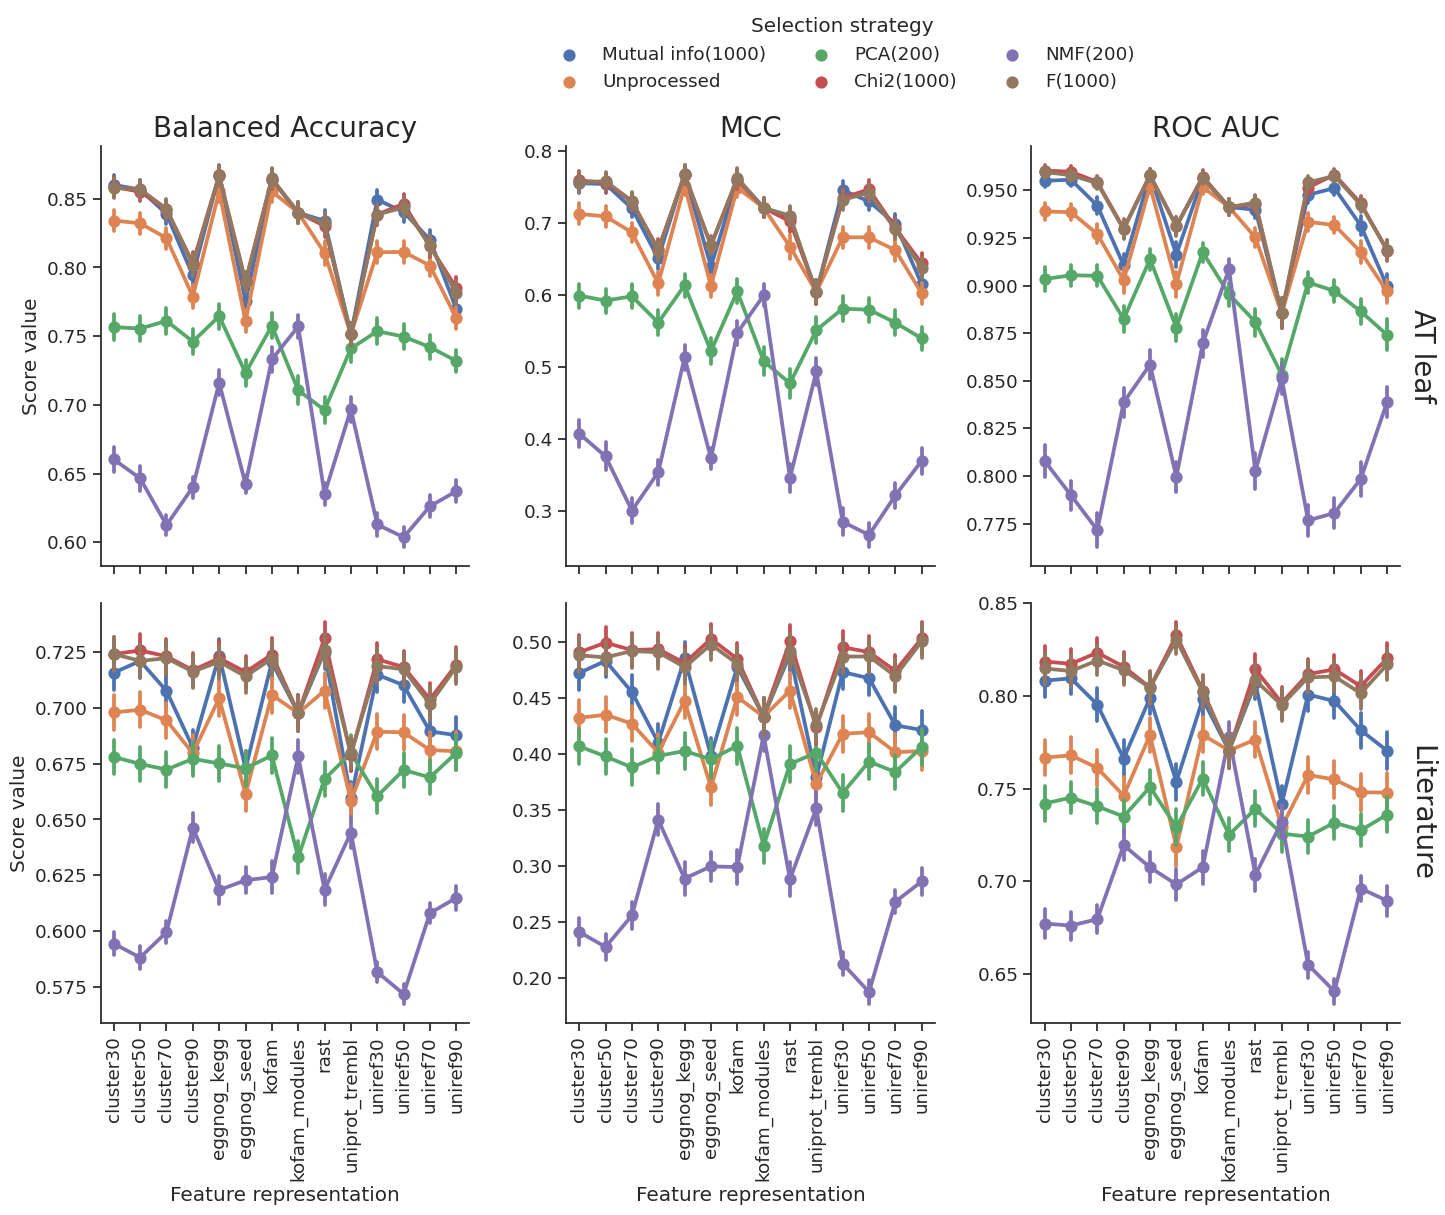

In [10]:
sns.set_theme(font_scale=1.2, style="ticks")

cols = score_columns
plot_data = (
    cv_scores_df
    .melt(id_vars=["Dataset", "Preprocessing strategy", "Feature representation"], value_vars=score_columns,
          var_name="Metric", value_name="Score value")
)
plot_data["Feature category"] = plot_data["Feature representation"].apply(group_feature)

g = sns.catplot(data=plot_data, x="Feature representation", y="Score value", errorbar="se",
                kind="point", col="Metric", row="Dataset",
                sharey=False, hue="Preprocessing strategy", margin_titles=True)
g.set_titles(row_template = '{row_name}', col_template = '{col_name}', size=20)
for i, ax in enumerate(g.axes.flat):
    ax.tick_params(axis='x', rotation=90, which="both");

sns.move_legend(g, "upper center", ncol=3, bbox_to_anchor=(0.5, 1.1), title="Selection strategy")
# TODO: Color map (gradient for same category)

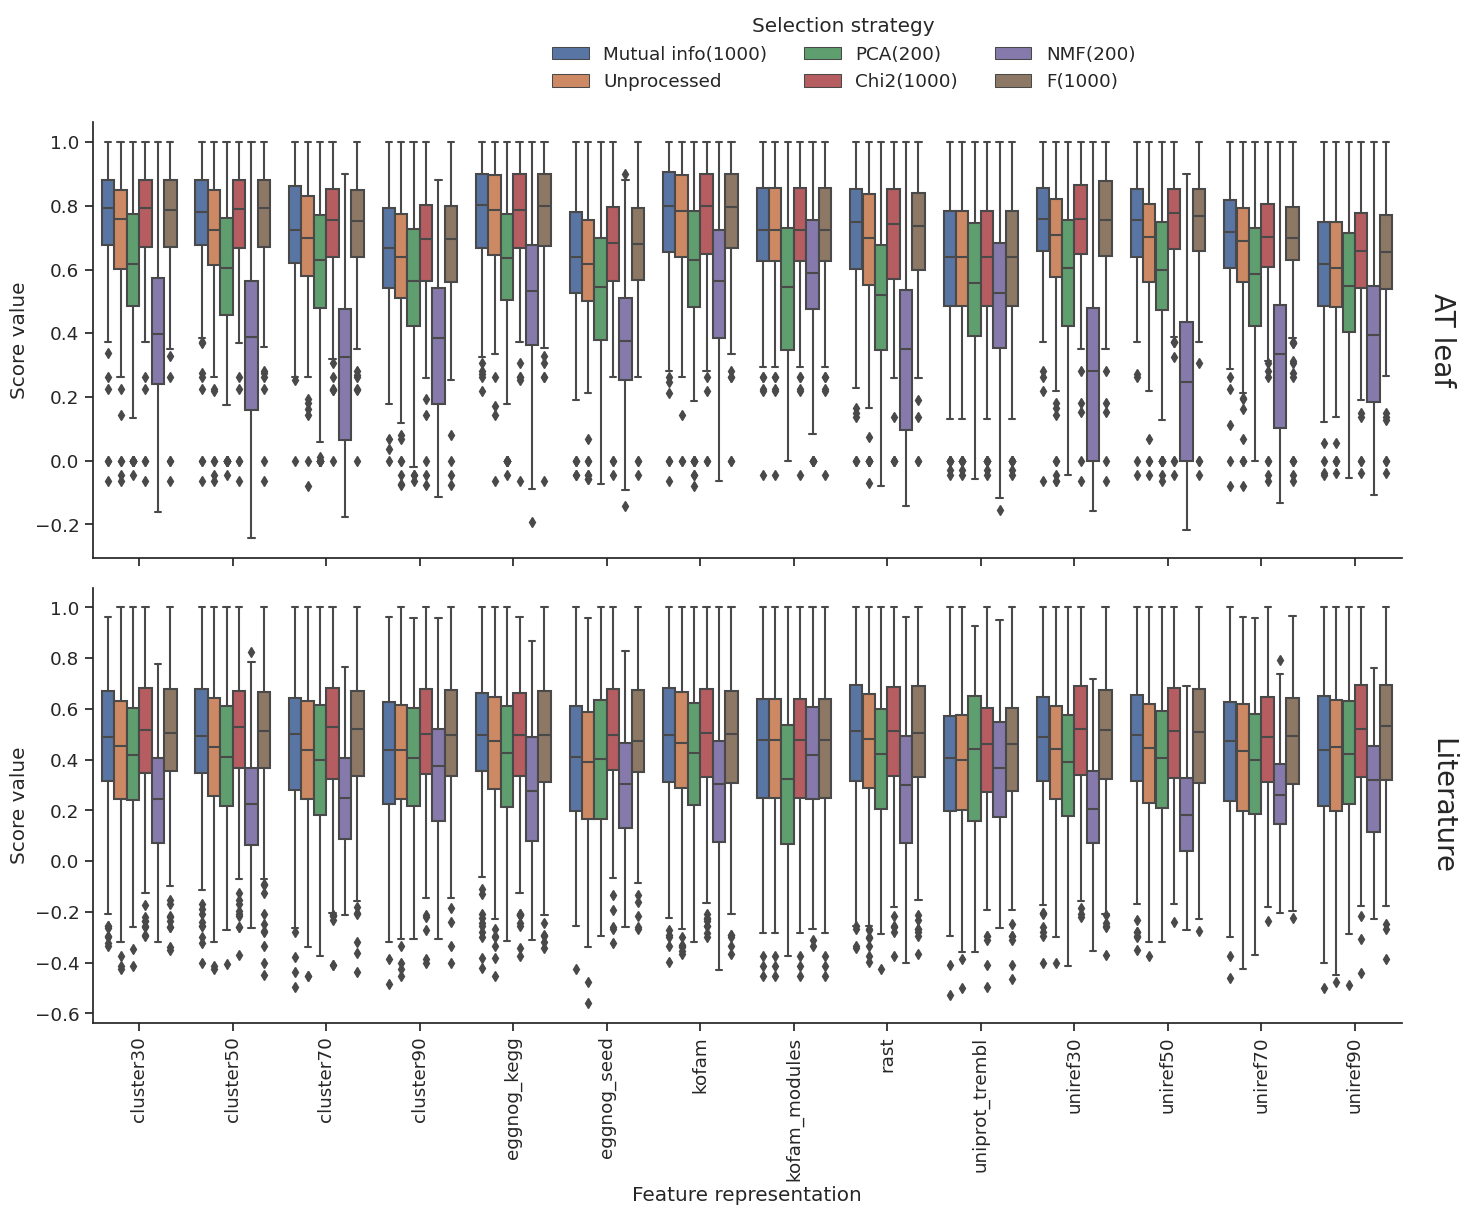

In [32]:
sns.set_theme(font_scale=1.2, style="ticks")

cols = ["MCC"]
plot_data = (
    cv_scores_df
    .melt(id_vars=["Dataset", "Preprocessing strategy", "Feature representation"], value_vars=cols,
          var_name="Metric", value_name="Score value")
)
plot_data["Feature category"] = plot_data["Feature representation"].apply(group_feature)

g = sns.catplot(data=plot_data, x="Feature representation", y="Score value",
                kind="box",  row="Dataset", aspect=3,
                sharey=False, hue="Preprocessing strategy", margin_titles=True)
g.set_titles(row_template = '{row_name}', col_template = '{col_name}', size=20)
for i, ax in enumerate(g.axes.flat):
    ax.tick_params(axis='x', rotation=90, which="both");

sns.move_legend(g, "upper center", ncol=3, bbox_to_anchor=(0.5, 1.1), title="Selection strategy")
# TODO: Color map (gradient for same category)

## Performance of different feature representations

In [11]:
cols = ["Dataset", "Feature representation"] + score_columns
(
    cv_scores_df
    .loc[cv_scores_df["Preprocessing strategy"] == "Chi2(1000)", cols]
    .groupby(["Dataset", "Feature representation"])
    .mean()
    .sort_values(by=["Balanced Accuracy"], ascending=False)
)

Balanced Accuracy       MCC   ROC AUC
Dataset    Feature representation                                       
AT leaf    eggnog_kegg                      0.867026  0.766716  0.958047
           kofam                            0.864255  0.760375  0.957230
           cluster30                        0.858712  0.759078  0.960386
           cluster50                        0.855146  0.756217  0.959807
           uniref50                         0.846381  0.746672  0.958248
           cluster70                        0.842158  0.729501  0.954405
           kofam_modules                    0.839959  0.721199  0.941223
           uniref30                         0.838511  0.734924  0.951468
           rast                             0.830193  0.702236  0.942782
           uniref70                         0.815391  0.692982  0.943184
           cluster90                        0.803141  0.663619  0.929917
           eggnog_seed                      0.789831  0.669283  0.931302
           uniref90                         0.785114  0.644015  0.918355
           uniprot_trembl                   0.751240  0.604284  0.885373
Literature rast                             0.731108  0.501010  0.814320
           cluster50                        0.725656  0.499553  0.817317
           cluster30                        0.724023  0.490832  0.818525
           kofam                            0.723812  0.485069  0.802888
           cluster70                        0.723034  0.492823  0.823351
           eggnog_kegg                      0.722167  0.481254  0.804572
           uniref30                         0.721714  0.495436  0.811788
           uniref90                         0.719250  0.503352  0.820259
           uniref50                         0.718238  0.491058  0.814284
           cluster90                        0.716810  0.493775  0.815714
           eggnog_seed                      0.716002  0.502889  0.832593
           uniref70                         0.703782  0.474232  0.805214
           kofam_modules                    0.697592  0.433378  0.770547
           uniprot_trembl                   0.678781  0.423661  0.796245

Best performers:
- EGGNOG KEGG for AT Leaf (also in top 3 for Literature)
- RAST for literature (in the middle for AT Leaf)

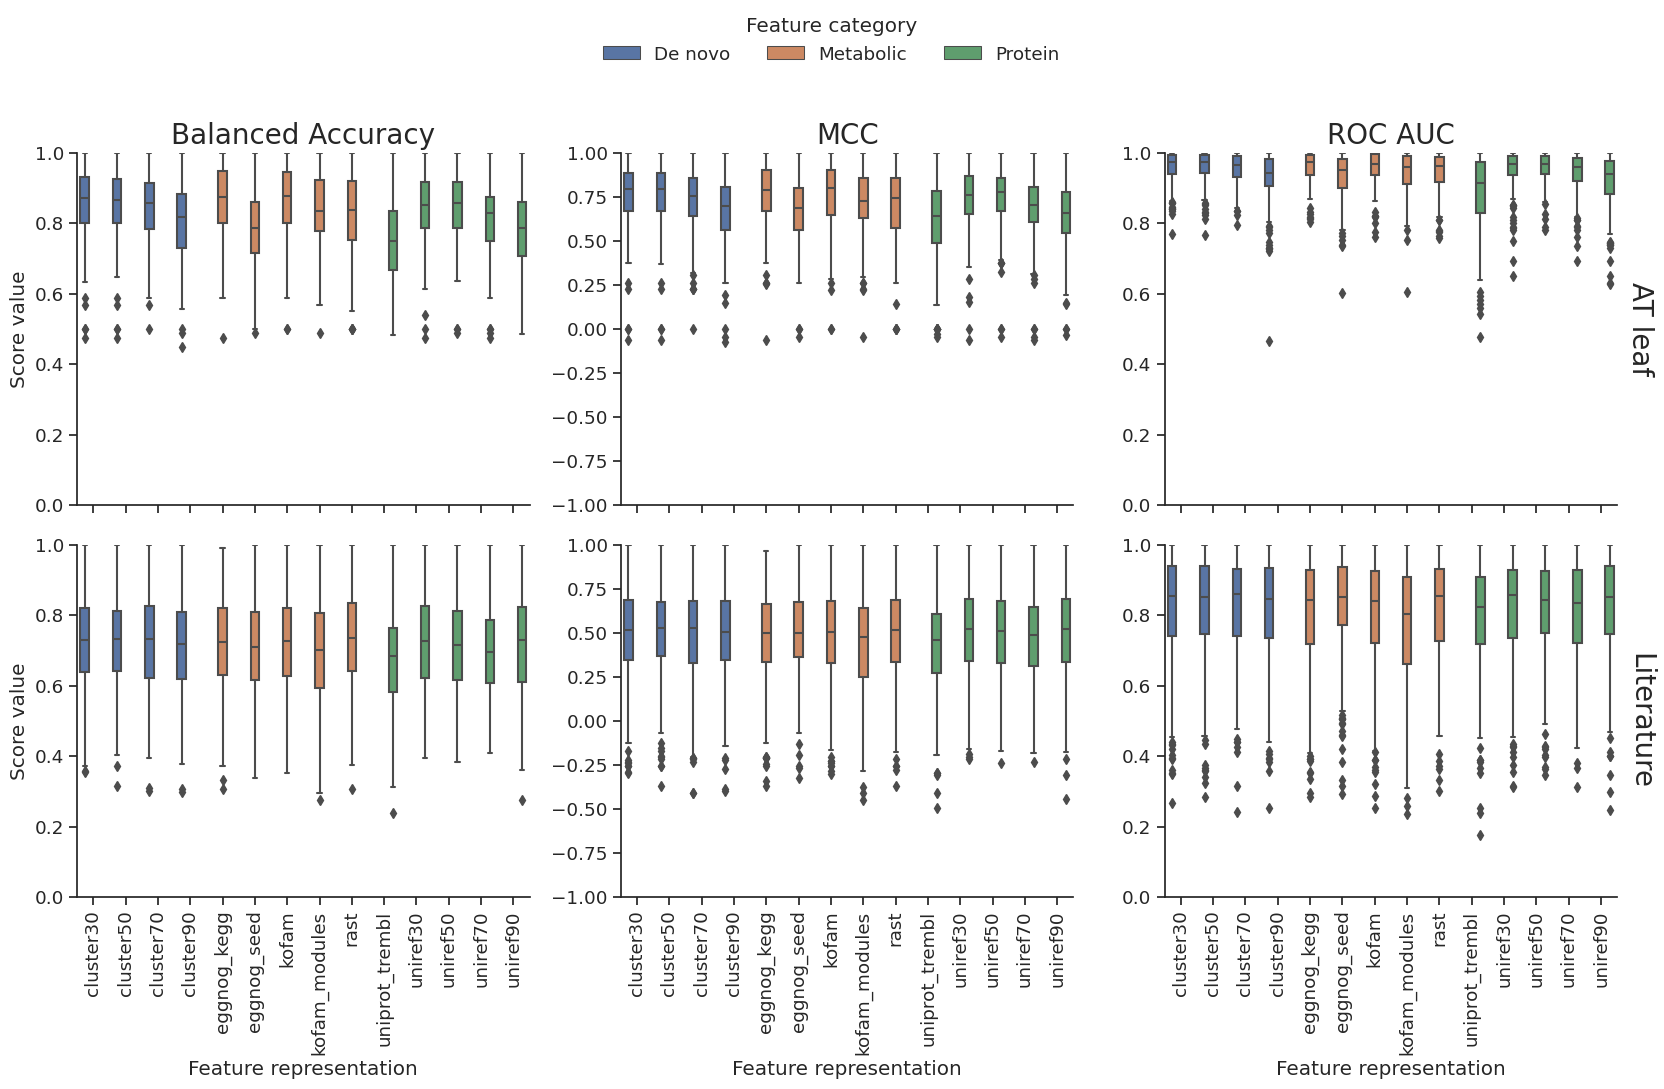

In [12]:
sns.set_theme(font_scale=1.2, style="ticks")

cols = score_columns + ["Feature representation", "Dataset"]
plot_data = (
    cv_scores_df
    .loc[cv_scores_df["Preprocessing strategy"] == "Chi2(1000)", cols]
    .melt(id_vars=["Feature representation", "Dataset"], value_vars=score_columns, var_name="Metric", value_name="Score value")
)
plot_data["Feature category"] = plot_data["Feature representation"].apply(group_feature)
g = sns.catplot(data=plot_data, x="Feature representation", y="Score value", col="Metric", row="Dataset", hue="Feature category",
                kind="box", sharey=False, sharex=True, margin_titles=True)
[plt.setp(ax.texts, text="") for ax in g.axes.flat] # remove the original texts
g.set_titles(row_template = '{row_name}', col_template = '{col_name}', size=20)
for i, ax in enumerate(g.axes.flat):
    ax.tick_params(axis='x', rotation=90, which="both");
    if i == 1 or i == 4:
        ax.set_ylim(-1, 1)
    else:
        ax.set_ylim(0, 1)
sns.move_legend(g, "upper center", ncol=3, bbox_to_anchor=(0.5, 1.1), title="Feature category")
plt.tight_layout()

## Clustermap

Are there any phenotypes that have the exact same names in the two datasets?

In [13]:
leaf_phenotypes = set(cv_scores_df["Phenotype"][cv_scores_df["Dataset"] == "AT leaf"])
lit_phenotypes = set(cv_scores_df["Phenotype"][cv_scores_df["Dataset"] == "Literature"])
len(leaf_phenotypes), len(lit_phenotypes)

(40, 64)

In [14]:
len(set(cv_scores_df["Phenotype"]))

104

This means that both the datasets use different names for the phenotypes

In [15]:
def make_colormap(df):
    phenotype_colormap = dict()
    dataset_colormap = {"AT leaf": "blue", "Literature": "orange"}
    for p, d in zip(df["Phenotype"], df["Dataset"]):
        phenotype_colormap[p] = dataset_colormap[d]
    return phenotype_colormap

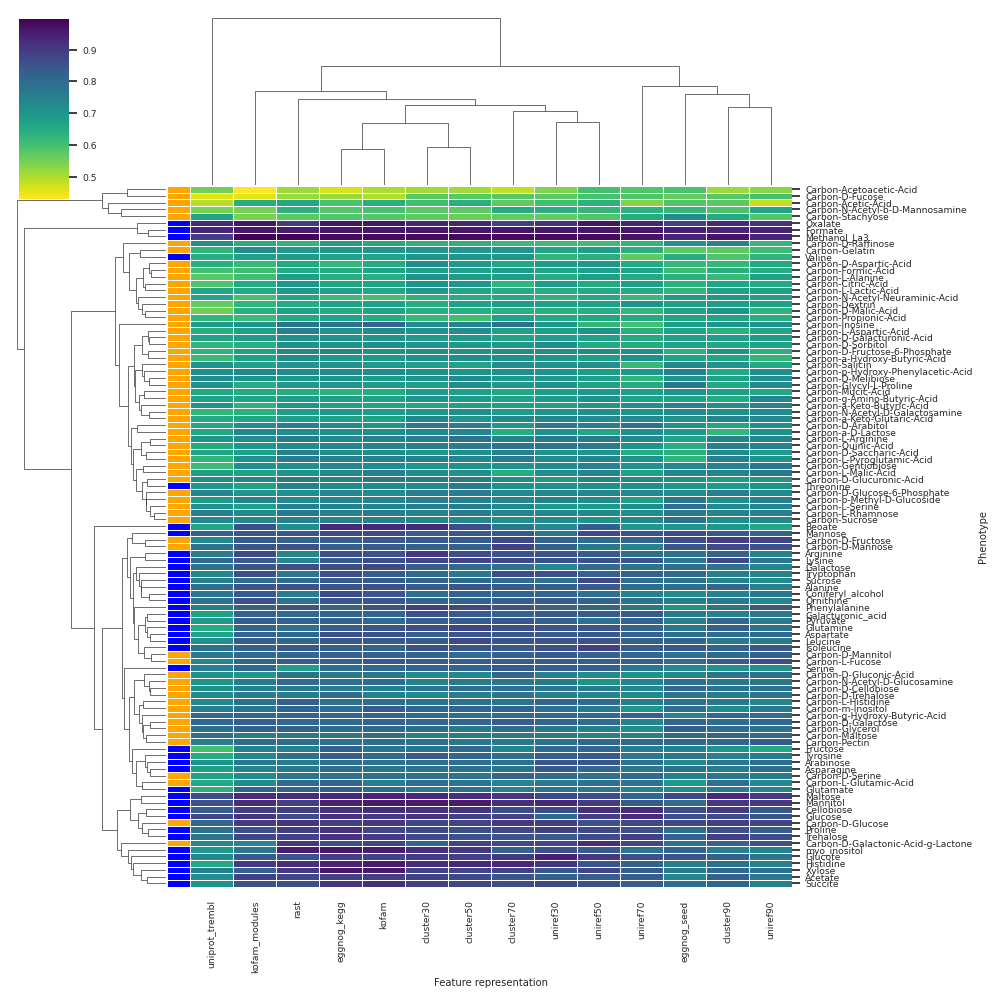

In [16]:
plot_data = (
    cv_scores_df
    .loc[cv_scores_df["Preprocessing strategy"] == "Chi2(1000)", ["Dataset", "Feature representation", "Phenotype", "Balanced Accuracy"]]
    .groupby(by=["Dataset", "Feature representation", "Phenotype"])
    .mean()
    .reset_index()
    .sort_values(by="Balanced Accuracy", ascending=False)
    .pivot(index="Phenotype", columns="Feature representation", values="Balanced Accuracy")
)
sns.set_theme(font_scale=0.6)
color_map = make_colormap(cv_scores_df)
row_colors = plot_data.index.map(color_map)
row_colors.name = "Dataset"
cmap = sns.color_palette("viridis", as_cmap=True).reversed()
g = sns.clustermap(plot_data,  linewidths=.5, cmap=cmap, yticklabels=1, row_colors=row_colors)

Which are the best features that we should choose for the combined feature representation?

In [17]:
plot_data.mean(axis=0).sort_values(ascending=False)

Feature representation
eggnog_kegg       0.777882
kofam             0.777829
cluster30         0.775826
cluster50         0.775460
rast              0.769218
cluster70         0.768851
uniref50          0.767524
uniref30          0.766636
kofam_modules     0.752348
cluster90         0.750014
uniref70          0.746708
uniref90          0.744583
eggnog_seed       0.744398
uniprot_trembl    0.706650
dtype: float64